# XAU/USD Next-Day Movement Forecasting
## From-Scratch Logistic Regression
### Multiclass classification: Up / Down (with adjustable Neutral zone)

This notebook mirrors the LSTM analysis exactly — same dataset, same features, same labelling, same train/val/test split, same backtest engine — but replaces the Keras LSTM with a **from-scratch Logistic Regression** implemented entirely in NumPy. No `sklearn`, no `tensorflow`, no model-library imports.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load dataset — same file used by the LSTM notebook
df = pd.read_csv("xauusd_macro.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
print(f"Loaded {len(df)} rows | {df['Date'].iloc[0].date()} → {df['Date'].iloc[-1].date()}")

Loaded 4041 rows | 2010-01-04 → 2026-01-30


In [3]:
# Helper functions — identical to LSTM notebook
def rsi(s, w=14):
    d = s.diff()
    g = d.clip(lower=0).ewm(alpha=1/w, adjust=False).mean()
    l = (-d).clip(lower=0).ewm(alpha=1/w, adjust=False).mean()
    return 100 - (100 / (1 + g / l.replace(0, np.nan)))

def atr(h, l, c, w=14):
    pc = c.shift(1)
    tr = pd.concat([h-l, (h-pc).abs(), (l-pc).abs()], axis=1).max(axis=1)
    return tr.ewm(alpha=1/w, adjust=False).mean()

def macd_hist(c, f=12, s=26, sig=9):
    line = c.ewm(span=f, adjust=False).mean() - c.ewm(span=s, adjust=False).mean()
    return line - line.ewm(span=sig, adjust=False).mean()

In [4]:
# Build features — identical feature set to the LSTM notebook
def build_features(df):
    d = df.copy()
    c, h, l = d["Close"], d["High"], d["Low"]
    dxy, vix, oil = d["DXY_Close"], d["VIX_Close"], d["Oil_Close"]
    ret1 = c.pct_change()

    # Original 10 features
    d["macd_hist"]     = macd_hist(c) / c
    d["rsi_14"]        = rsi(c)
    d["atr_pct"]       = atr(h, l, c) / c
    d["ret_5"]         = c.pct_change(5)
    d["ret_21"]        = c.pct_change(21)
    d["vol_ratio"]     = ret1.rolling(5).std() / ret1.rolling(21).std().replace(0, np.nan)
    d["dxy_ret5"]      = dxy.pct_change(5)
    d["vix_chg"]       = vix.diff()
    d["oil_ret5"]      = oil.pct_change(5)
    d["gold_dxy_corr"] = ret1.rolling(21).corr(dxy.pct_change())

    # Macro features from xauusd_macro.csv
    d["real_yield_chg"]    = d["real_yield_10y"].diff()
    d["real_yield_5d_chg"] = d["real_yield_10y"].diff(5)
    d["breakeven_chg"]     = d["breakeven_10y"].diff()
    d["hy_spread_chg"]     = d["hy_spread"].diff()

    # GPR z-score (column absent in base CSV → fill with 0)
    if "gpr_index" in d.columns:
        gpr_mean = d["gpr_index"].rolling(63).mean()
        gpr_std  = d["gpr_index"].rolling(63).std().replace(0, np.nan)
        d["gpr_zscore"] = (d["gpr_index"] - gpr_mean) / gpr_std
    else:
        d["gpr_zscore"] = 0.0

    return d

df = build_features(df)

In [5]:
FEATURES = [
    # Original 10
    "macd_hist", "rsi_14", "atr_pct", "ret_5", "ret_21",
    "vol_ratio", "dxy_ret5", "vix_chg", "oil_ret5", "gold_dxy_corr",
    # Macro
    "real_yield_chg", "real_yield_5d_chg", "breakeven_chg", "hy_spread_chg",
    "fomc_week", "macro_event_week", "gpr_zscore",
]

FWD = 5   # 5-day forward return — same as LSTM

# Labelling: top/bottom 30 % quantile (same thresholds as LSTM)
df["fwd_ret_5"] = df["Close"].shift(-FWD) / df["Close"] - 1
q_lo = df["fwd_ret_5"].quantile(0.40)
q_hi = df["fwd_ret_5"].quantile(0.60)
df["label"] = np.nan
df.loc[df["fwd_ret_5"] >= q_hi, "label"] = 1   # Up
df.loc[df["fwd_ret_5"] <= q_lo, "label"] = 0   # Down

df_clean = df.dropna(subset=FEATURES + ["label"]).reset_index(drop=True)

print(f"Rows after dropna : {len(df_clean)}")
print(f"Date range        : {df_clean['Date'].iloc[0].date()} → {df_clean['Date'].iloc[-1].date()}")
print(f"Label distribution: Up={int((df_clean['label']==1).sum())}  Down={int((df_clean['label']==0).sum())}")

Rows after dropna : 3210
Date range        : 2010-02-03 → 2026-01-23
Label distribution: Up=1609  Down=1601


In [6]:
# Train / Val / Test split — same boundaries as the LSTM notebook
TRAIN_END = "2022-12-31"
VAL_END   = "2024-03-31"

tr = df_clean[df_clean["Date"] <= TRAIN_END]
va = df_clean[(df_clean["Date"] > TRAIN_END) & (df_clean["Date"] <= VAL_END)]
te = df_clean[df_clean["Date"] > VAL_END].copy()

print(f"Train : {len(tr)} rows ({tr['Date'].iloc[0].date()} → {tr['Date'].iloc[-1].date()})")
print(f"Val   : {len(va)} rows ({va['Date'].iloc[0].date()} → {va['Date'].iloc[-1].date()})")
print(f"Test  : {len(te)} rows ({te['Date'].iloc[0].date()} → {te['Date'].iloc[-1].date()})")

Train : 2585 rows (2010-02-03 → 2022-12-30)
Val   : 244 rows (2023-01-03 → 2024-03-28)
Test  : 381 rows (2024-04-01 → 2026-01-23)


## From-Scratch Components

The following classes are implemented **entirely in NumPy** — no scikit-learn, no TensorFlow.

> **Why no early stopping?**  
> Early stopping and learning-rate schedules are regularisation tricks for *non-convex* neural-network loss surfaces.  
> The Binary Cross-Entropy loss of logistic regression is **strictly convex** in the parameters, so gradient descent is guaranteed to converge to the unique global minimum.  
> Instead of early stopping we use a **convergence criterion**: we stop as soon as the maximum absolute parameter change between consecutive iterations falls below a tolerance `eps` — i.e. `max(|β_new − β_old|) < eps`.

In [7]:
# ── 1. Standard Scaler (from scratch) ──────────────────────────────────────
class StandardScalerScratch:
    """Standardise features to zero mean, unit variance.
    Mirrors sklearn.preprocessing.StandardScaler but uses only NumPy.
    """
    def fit(self, X):
        self.mu_    = X.mean(axis=0)
        self.sigma_ = X.std(axis=0)
        return self

    def transform(self, X):
        return (X - self.mu_) / (self.sigma_ + 1e-8)

    def fit_transform(self, X):
        return self.fit(X).transform(X)

sc  = StandardScalerScratch()
Xtr = sc.fit_transform(tr[FEATURES].values.astype(float))
Xva = sc.transform(va[FEATURES].values.astype(float))
Xte = sc.transform(te[FEATURES].values.astype(float))
ytr = tr["label"].astype(int).values
yva = va["label"].astype(int).values
yte = te["label"].astype(int).values

print(f"Xtr shape: {Xtr.shape}  Xva: {Xva.shape}  Xte: {Xte.shape}")

Xtr shape: (2585, 17)  Xva: (244, 17)  Xte: (381, 17)


In [8]:
# ── 2. Balanced Class Weights (from scratch) ───────────────────────────────
def compute_class_weights(y):
    """Return per-class scalar weights so minority class is up-weighted.
    Formula: weight_k = n_samples / (n_classes * count_k)
    Mirrors sklearn.utils.class_weight.compute_class_weight('balanced', ...)
    """
    classes = np.unique(y)
    n       = len(y)
    return {c: n / (len(classes) * (y == c).sum()) for c in classes}

cw_dict           = compute_class_weights(ytr)
sample_weights_tr = np.where(ytr == 1, cw_dict[1], cw_dict[0])
print("Class weights:", {k: round(v, 4) for k, v in cw_dict.items()})

Class weights: {np.int64(0): np.float64(0.966), np.int64(1): np.float64(1.0365)}


In [9]:
# ── 3. Logistic Regression — from scratch ──────────────────────────────────
class LogisticRegressionScratch:
    """Binary Logistic Regression trained with gradient descent.

    Because Binary Cross-Entropy is a *convex* function of the parameters,
    gradient descent converges to the unique global minimum.  No early
    stopping or learning-rate schedule is required.

    Stopping rule (professor's suggestion):
        Stop when  max(|β_new − β_old|) < eps
    i.e. when every parameter has moved by less than eps in a single step,
    indicating the optimiser has effectively converged.

    Parameters
    ----------
    lr       : learning rate (step size for gradient descent)
    max_iter : hard upper bound on iterations (safety net)
    lambda_  : L2 regularisation strength  (penalises large weights)
    eps      : convergence tolerance — default 1e-4 as suggested
    """

    def __init__(self, lr=0.05, max_iter=2000, lambda_=0.01, eps=1e-4):
        self.lr       = lr
        self.max_iter = max_iter
        self.lambda_  = lambda_
        self.eps      = eps

    # ── activation ──────────────────────────────────────────────────────────
    def _sigmoid(self, z):
        """Numerically stable sigmoid: σ(z) = 1 / (1 + e^{-z})."""
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

    # ── weighted BCE loss (for tracking only) ───────────────────────────────
    def _bce_loss(self, X, y, sw):
        """Weighted Binary Cross-Entropy + L2 penalty.
        Used only for loss tracking, not for the stopping rule.
        """
        prob = np.clip(self._sigmoid(X @ self.w_ + self.b_), 1e-9, 1 - 1e-9)
        bce  = -(sw * (y * np.log(prob) + (1 - y) * np.log(1 - prob))).mean()
        l2   = (self.lambda_ / 2) * np.dot(self.w_, self.w_)
        return bce + l2

    # ── training loop ────────────────────────────────────────────────────────
    def fit(self, X, y, sample_weights=None):
        """Gradient descent with parameter-change convergence criterion.

        Stopping condition:
            max(|w_new − w_old|, |b_new − b_old|) < self.eps
        """
        n, p = X.shape
        self.w_      = np.zeros(p)
        self.b_      = 0.0
        self.losses_ = []
        self.n_iter_ = 0

        if sample_weights is None:
            sample_weights = np.ones(n)

        for i in range(self.max_iter):
            # ── save current parameters before update ────────────────────────
            w_old = self.w_.copy()
            b_old = self.b_

            # ── forward pass ─────────────────────────────────────────────────
            prob = self._sigmoid(X @ self.w_ + self.b_)
            err  = prob - y                        # prediction residuals

            # ── gradients (weighted) + L2 regularisation on weights ──────────
            grad_w = (X.T @ (err * sample_weights)) / n + self.lambda_ * self.w_
            grad_b = (err * sample_weights).mean()

            # ── gradient descent parameter update ────────────────────────────
            self.w_ -= self.lr * grad_w
            self.b_ -= self.lr * grad_b

            # ── track loss ───────────────────────────────────────────────────
            self.losses_.append(self._bce_loss(X, y, sample_weights))
            self.n_iter_ = i + 1

            # ── convergence check ─────────────────────────────────────────────
            # Stop when the largest parameter change is smaller than eps.
            # This is the correct stopping rule for a convex optimisation problem.
            delta = max(np.max(np.abs(self.w_ - w_old)), abs(self.b_ - b_old))
            if delta < self.eps:
                print(f"  Converged at iteration {i + 1}  "                      f"(max|Δβ| = {delta:.2e} < eps={self.eps})")
                break
        else:
            print(f"  Reached max_iter={self.max_iter} without full convergence "                  f"(max|Δβ| = {delta:.2e})")

        return self

    # ── inference ────────────────────────────────────────────────────────────
    def predict_proba(self, X):
        """Return P(class=1 | X) for each sample."""
        return self._sigmoid(X @ self.w_ + self.b_)

    def predict(self, X, threshold=0.5):
        """Hard binary prediction using decision boundary at `threshold`."""
        return (self.predict_proba(X) >= threshold).astype(int)

In [10]:
# ── 4. Train the model ──────────────────────────────────────────────────────
# No validation set is passed to .fit() — the model stops via the
# convergence criterion, not by monitoring a held-out loss.
print("Training Logistic Regression (from scratch)...")

model = LogisticRegressionScratch(
    lr       = 0.05,     # learning rate
    max_iter = 2000,     # hard cap (safety net — convergence fires first)
    lambda_  = 0.01,     # L2 regularisation
    eps      = 1e-4,     # convergence tolerance  max(|Δβ|) < eps
)
model.fit(Xtr, ytr, sample_weights=sample_weights_tr)

print(f"Training done  ({model.n_iter_} iterations).")

# Quick validation accuracy for reference
val_pred = model.predict(Xva)
val_acc  = (val_pred == yva).mean()
print(f"Validation Accuracy: {val_acc:.4f}")

Training Logistic Regression (from scratch)...
  Converged at iteration 973  (max|Δβ| = 9.99e-05 < eps=0.0001)
Training done  (973 iterations).
Validation Accuracy: 0.4713


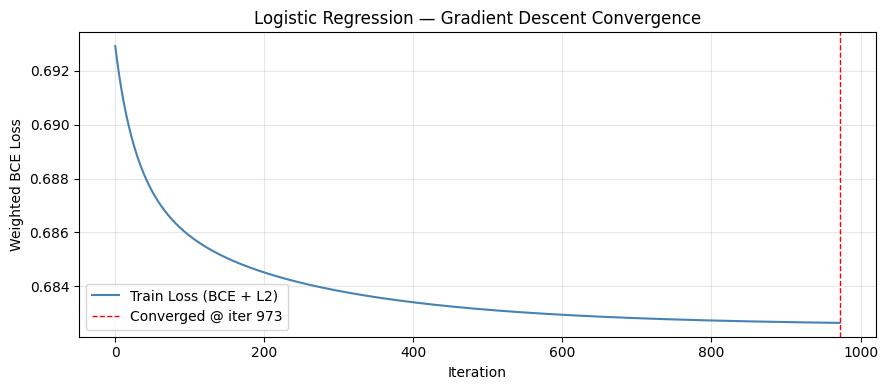

In [11]:
# Plot training loss curve — shows convergence of the gradient descent
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(model.losses_, color="steelblue", linewidth=1.5, label="Train Loss (BCE + L2)")
ax.axvline(model.n_iter_ - 1, color="red", linestyle="--", linewidth=1,
           label=f"Converged @ iter {model.n_iter_}")
ax.set_title("Logistic Regression — Gradient Descent Convergence")
ax.set_xlabel("Iteration")
ax.set_ylabel("Weighted BCE Loss")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

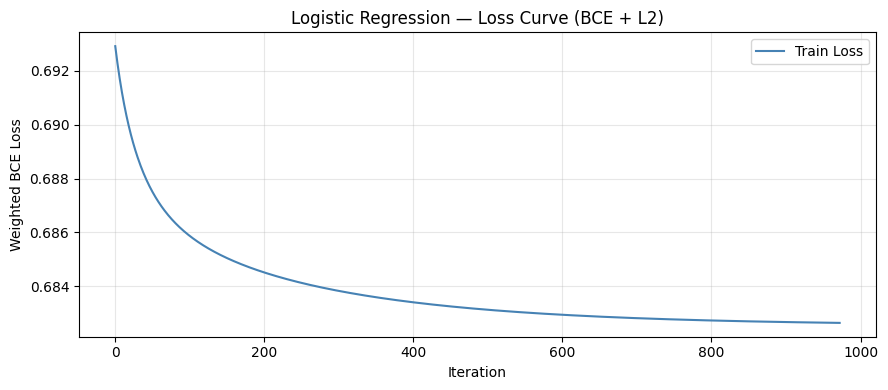

In [12]:
# Plot training loss curve
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(model.losses_, label="Train Loss", color="steelblue", linewidth=1.5)
ax.set_title("Logistic Regression — Loss Curve (BCE + L2)")
ax.set_xlabel("Iteration")
ax.set_ylabel("Weighted BCE Loss")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# ── 5. From-Scratch Metrics ─────────────────────────────────────────────────

def accuracy_scratch(y_true, y_pred):
    return (y_true == y_pred).mean()

def mse_scratch(y_true, y_score):
    """MSE between true labels and continuous scores (prob or hard pred)."""
    return ((y_true - y_score) ** 2).mean()

def precision_scratch(y_true, y_pred):
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def recall_scratch(y_true, y_pred):
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def f1_scratch(y_true, y_pred):
    p = precision_scratch(y_true, y_pred)
    r = recall_scratch(y_true, y_pred)
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0

# ── Predictions ─────────────────────────────────────────────────────────────
val_prob  = model.predict_proba(Xva)
val_pred  = model.predict(Xva)
test_prob = model.predict_proba(Xte)
test_pred = model.predict(Xte)

# ── Report ───────────────────────────────────────────────────────────────────
print("=== Validation Metrics ===")
print(f"Accuracy : {accuracy_scratch(yva, val_pred):.4f}")
print(f"MSE(prob): {mse_scratch(yva, val_prob):.4f}")
print(f"MSE(pred): {mse_scratch(yva, val_pred):.4f}")
print(f"Precision: {precision_scratch(yva, val_pred):.4f}")
print(f"Recall   : {recall_scratch(yva, val_pred):.4f}")
print(f"F1-score : {f1_scratch(yva, val_pred):.4f}")

print("\n=== Test Metrics ===")
print(f"Accuracy : {accuracy_scratch(yte, test_pred):.4f}")
print(f"MSE(prob): {mse_scratch(yte, test_prob):.4f}")
print(f"MSE(pred): {mse_scratch(yte, test_pred):.4f}")
print(f"Precision: {precision_scratch(yte, test_pred):.4f}")
print(f"Recall   : {recall_scratch(yte, test_pred):.4f}")
print(f"F1-score : {f1_scratch(yte, test_pred):.4f}")

=== Validation Metrics ===
Accuracy : 0.4713
MSE(prob): 0.2558
MSE(pred): 0.5287
Precision: 0.4362
Recall   : 0.3504
F1-score : 0.3886

=== Test Metrics ===
Accuracy : 0.5512
MSE(prob): 0.2455
MSE(pred): 0.4488
Precision: 0.7176
Recall   : 0.4980
F1-score : 0.5880


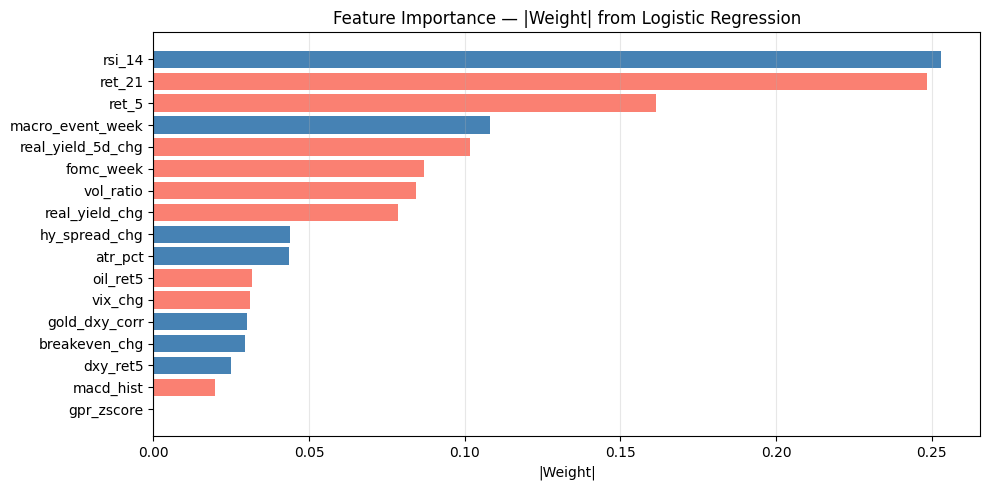


Top-5 features (blue = bullish signal, red = bearish signal):
  rsi_14                  w=+0.2529  (bullish)
  ret_21                  w=-0.2484  (bearish)
  ret_5                   w=-0.1613  (bearish)
  macro_event_week        w=+0.1082  (bullish)
  real_yield_5d_chg       w=-0.1017  (bearish)


In [14]:
# ── 6. Feature Importance (learned weights) ─────────────────────────────────
# In logistic regression the absolute magnitude of each weight reflects
# how strongly that feature pushes the probability toward Up (w>0) or Down (w<0).

importances = np.abs(model.w_)
order       = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
colors  = ["steelblue" if model.w_[i] > 0 else "salmon" for i in order]
ax.barh([FEATURES[i] for i in order][::-1],
        importances[order][::-1],
        color=colors[::-1])
ax.set_title("Feature Importance — |Weight| from Logistic Regression")
ax.set_xlabel("|Weight|")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

print("\nTop-5 features (blue = bullish signal, red = bearish signal):")
for i in order[:5]:
    direction = "bullish" if model.w_[i] > 0 else "bearish"
    print(f"  {FEATURES[i]:<22}  w={model.w_[i]:+.4f}  ({direction})")

In [15]:
# ── 7. Build Signal DataFrame ───────────────────────────────────────────────
# Identical structure to LSTM notebook so the same backtest engine can be reused.

test_dates = te["Date"].values
test_close = te["Close"].values
test_fwd   = te["fwd_ret_5"].values
test_true  = yte

signal_df = pd.DataFrame({
    "Date":       test_dates,
    "Close":      test_close,
    "prob_up":    test_prob,
    "signal":     np.where(test_prob >= 0.5, 1, -1),   # 1=Long, -1=Short
    "true_label": test_true,
    "fwd_ret_5":  test_fwd,
})
signal_df["Date"] = pd.to_datetime(signal_df["Date"])
print(f"Signal DataFrame: {len(signal_df)} rows")
print(f"Long signals : {(signal_df['signal']==1).sum()}")
print(f"Short signals: {(signal_df['signal']==-1).sum()}")

Signal DataFrame: 381 rows
Long signals : 170
Short signals: 211


In [16]:
# ── 8. Backtest Engine ──────────────────────────────────────────────────────
# Identical to the LSTM notebook — same rules, same stop-loss logic.

INITIAL_CAPITAL   = 100_000
POSITION_SIZE_PCT = 1.00
SPREAD_PCT        = 0.0002
CONF_THRESHOLD    = 0.25
STOP_LOSS_PCT     = 0.015

def run_backtest(signal_df, initial_capital, pos_size_pct,
                 spread_pct, conf_threshold, stop_loss_pct, label="Strategy"):
    """
    Stop-loss logic:
      - Hold each position for exactly FWD=5 days.
      - Only one position at a time (no overlapping trades).
      - Entry at Close on signal day; exit at Close 5 days later.
      - If any intra-holding daily close moves more than stop_loss_pct
        against the position we exit early at that close.
      - Transaction cost = spread_pct round-trip.
    """
    equity       = initial_capital
    equity_curve = [equity]
    dates_curve  = [signal_df["Date"].iloc[0]]
    trades       = []
    i            = 0

    while i < len(signal_df):
        row = signal_df.iloc[i]

        confident = (row["prob_up"] >= conf_threshold) or                     (row["prob_up"] <= (1 - conf_threshold))
        if not confident:
            i += 1
            equity_curve.append(equity)
            dates_curve.append(row["Date"])
            continue

        direction   = 1 if row["prob_up"] >= 0.5 else -1
        entry_price = row["Close"]
        entry_date  = row["Date"]

        stopped_out = False
        exit_price  = entry_price * (1 + row["fwd_ret_5"])
        exit_date   = entry_date + pd.Timedelta(days=FWD)

        future = signal_df.iloc[i+1 : i+FWD+1]
        for _, frow in future.iterrows():
            daily_move = direction * (frow["Close"] / entry_price - 1)
            if daily_move <= -stop_loss_pct:
                exit_price  = frow["Close"]
                exit_date   = frow["Date"]
                stopped_out = True
                break

        position_value = equity * pos_size_pct
        gross_ret      = direction * (exit_price / entry_price - 1)
        net_ret        = gross_ret - spread_pct
        pnl            = position_value * net_ret
        equity        += pnl

        trades.append({
            "entry_date":  entry_date,
            "exit_date":   exit_date,
            "direction":   "Long" if direction == 1 else "Short",
            "entry_price": round(entry_price, 2),
            "exit_price":  round(exit_price, 2),
            "gross_ret":   round(gross_ret * 100, 3),
            "net_ret":     round(net_ret * 100, 3),
            "pnl":         round(pnl, 2),
            "equity":      round(equity, 2),
            "win":         pnl > 0,
            "stopped_out": stopped_out,
        })

        i += FWD
        equity_curve.append(equity)
        dates_curve.append(row["Date"])

    trades_df = pd.DataFrame(trades)
    eq_df     = pd.DataFrame({"Date": dates_curve, "Equity": equity_curve})
    return trades_df, eq_df

In [17]:
# ── 9. Run Backtest ─────────────────────────────────────────────────────────
trades_df, eq_df = run_backtest(
    signal_df, INITIAL_CAPITAL, POSITION_SIZE_PCT,
    SPREAD_PCT, CONF_THRESHOLD, STOP_LOSS_PCT, "LR Strategy"
)

# Buy-and-hold benchmark
bh_ret    = (signal_df["Close"].iloc[-1] / signal_df["Close"].iloc[0]) - 1
bh_equity = INITIAL_CAPITAL * (1 + bh_ret * POSITION_SIZE_PCT)

In [18]:
# ── 10. Performance Metrics ─────────────────────────────────────────────────
def calc_performance(trades_df, eq_df, initial_capital):
    if len(trades_df) == 0:
        print("No trades executed.")
        return

    final_eq      = eq_df["Equity"].iloc[-1]
    total_return  = (final_eq - initial_capital) / initial_capital * 100
    wins          = trades_df["win"].sum()
    losses        = (~trades_df["win"]).sum()
    win_rate      = wins / len(trades_df) * 100
    avg_win       = trades_df.loc[trades_df["win"],  "net_ret"].mean()
    avg_loss      = trades_df.loc[~trades_df["win"], "net_ret"].mean()
    profit_factor = (trades_df.loc[trades_df["win"],  "pnl"].sum() /
                     abs(trades_df.loc[~trades_df["win"], "pnl"].sum())
                     if losses > 0 else np.inf)

    eq_series  = eq_df["Equity"]
    roll_max   = eq_series.cummax()
    drawdown   = (eq_series - roll_max) / roll_max * 100
    max_dd     = drawdown.min()

    n_days     = (eq_df["Date"].iloc[-1] - eq_df["Date"].iloc[0]).days
    ann_return = ((final_eq / initial_capital) ** (365 / max(n_days, 1)) - 1) * 100

    trade_rets = trades_df["net_ret"].values / 100
    sharpe     = (trade_rets.mean() / trade_rets.std() * np.sqrt(252 / FWD)
                  if trade_rets.std() > 0 else 0)

    print("\n" + "="*55)
    print("BACKTEST PERFORMANCE REPORT")
    print("="*55)
    print(f"\n  {'Initial Capital':<30} ${initial_capital:>10,.2f}")
    print(f"  {'Final Equity':<30} ${final_eq:>10,.2f}")
    print(f"  {'Total Return':<30} {total_return:>+10.2f}%")
    print(f"  {'Annualized Return':<30} {ann_return:>+10.2f}%")
    print(f"\n  {'Total Trades':<30} {len(trades_df):>10}")
    print(f"  {'Wins':<30} {wins:>10}")
    print(f"  {'Losses':<30} {losses:>10}")
    print(f"  {'Win Rate':<30} {win_rate:>10.1f}%")
    print(f"  {'Avg Win':<30} {avg_win:>+10.3f}%")
    print(f"  {'Avg Loss':<30} {avg_loss:>+10.3f}%")
    print(f"  {'Profit Factor':<30} {profit_factor:>10.2f}")
    print(f"  {'Max Drawdown':<30} {max_dd:>10.2f}%")
    print(f"  {'Sharpe Ratio':<30} {sharpe:>10.2f}")
    print(f"\n  {'Spread cost per trade':<30} {SPREAD_PCT*100:>10.3f}%")
    print(f"  {'Position size':<30} {POSITION_SIZE_PCT*100:>10.0f}% of equity")
    print(f"  {'Hold period':<30} {FWD:>10} days")
    print(f"\n  {'Buy & Hold return (same size)':<30} {(bh_equity-initial_capital)/initial_capital*100:>+10.2f}%")

    return {
        "total_return": total_return, "win_rate": win_rate,
        "max_dd": max_dd, "sharpe": sharpe, "profit_factor": profit_factor,
    }

perf = calc_performance(trades_df, eq_df, INITIAL_CAPITAL)

print("\nLast 10 trades:")
print(trades_df[["entry_date","direction","entry_price","exit_price",
                  "gross_ret","net_ret","pnl","equity"]].tail(10).to_string(index=False))


BACKTEST PERFORMANCE REPORT

  Initial Capital                $100,000.00
  Final Equity                   $101,176.20
  Total Return                        +1.18%
  Annualized Return                   +0.65%

  Total Trades                           77
  Wins                                   37
  Losses                                 40
  Win Rate                             48.1%
  Avg Win                            +2.404%
  Avg Loss                           -2.134%
  Profit Factor                        1.01
  Max Drawdown                       -12.64%
  Sharpe Ratio                         0.13

  Spread cost per trade               0.020%
  Position size                         100% of equity
  Hold period                             5 days

  Buy & Hold return (same size)     +122.50%

Last 10 trades:
entry_date direction  entry_price  exit_price  gross_ret  net_ret      pnl    equity
2025-11-11      Long       4106.8      4061.3     -1.108   -1.128 -1158.01 101510.02
2025-1

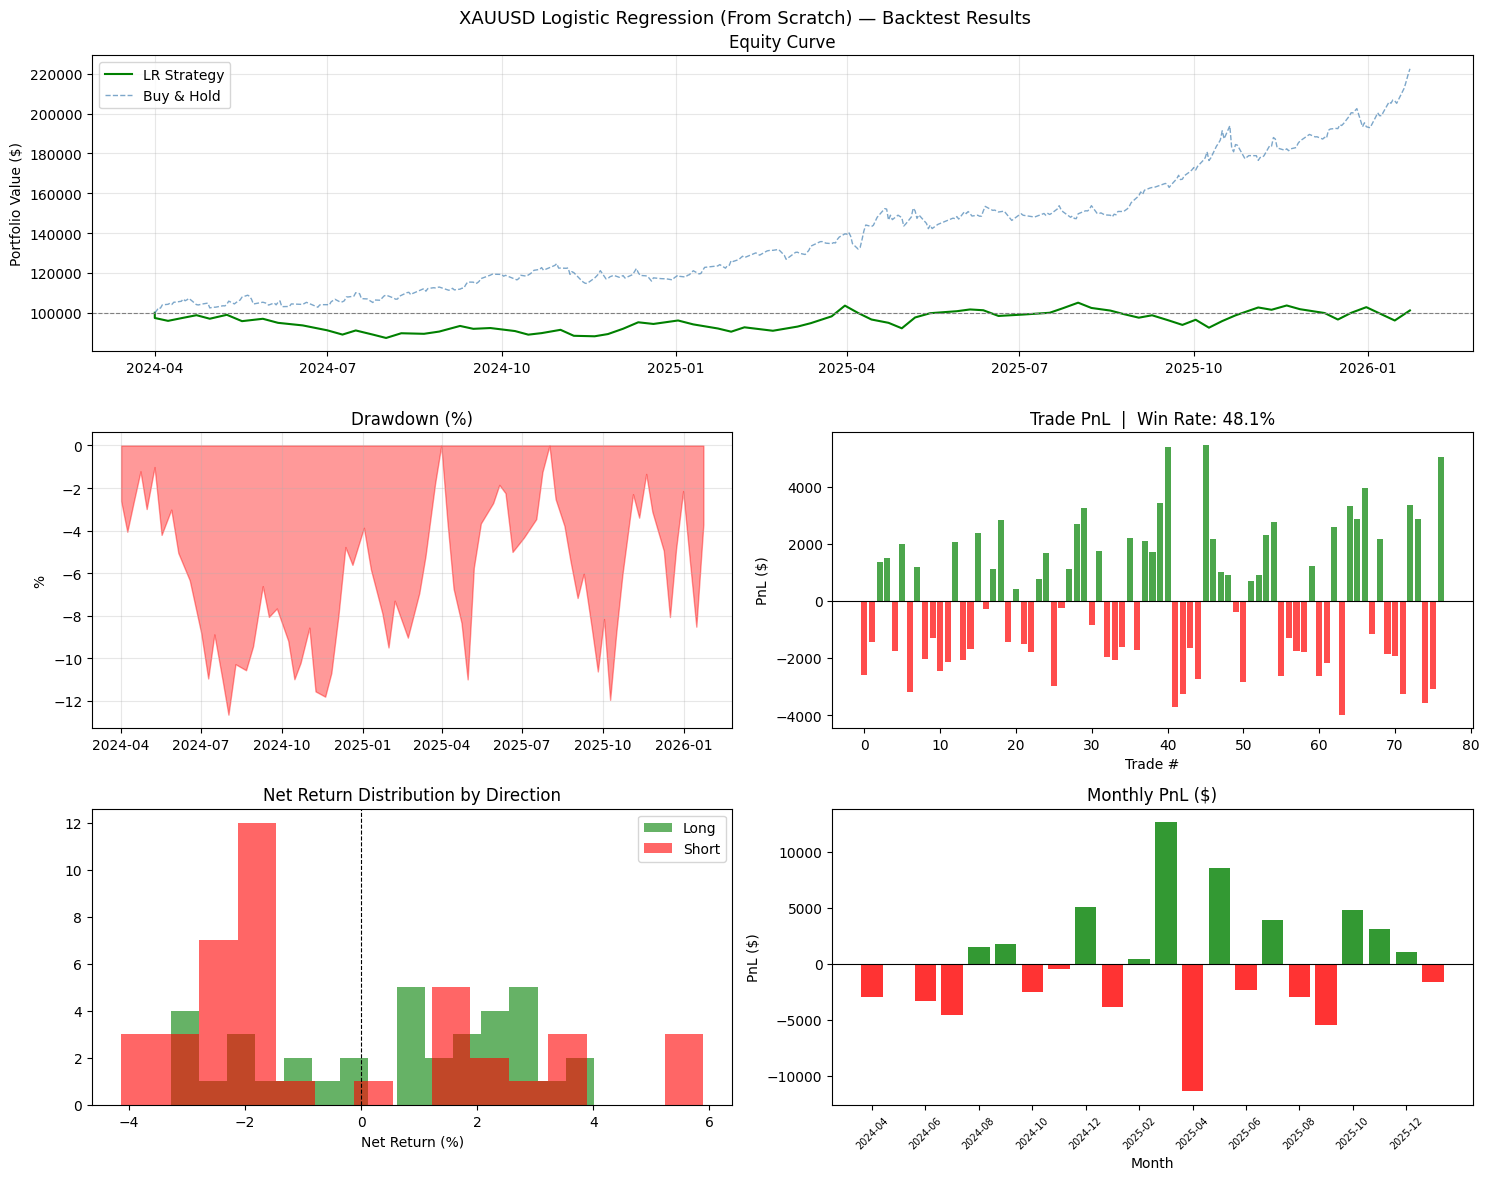

In [19]:
# ── 11. Plots ───────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 12))
gs  = gridspec.GridSpec(3, 2, figure=fig)
fig.suptitle("XAUUSD Logistic Regression (From Scratch) — Backtest Results", fontsize=13)

# Equity curve
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(eq_df["Date"], eq_df["Equity"], color="green",
         linewidth=1.5, label="LR Strategy")
ax1.axhline(INITIAL_CAPITAL, color="gray", linestyle="--", linewidth=0.8)
bh_curve = INITIAL_CAPITAL + (signal_df["Close"] / signal_df["Close"].iloc[0] - 1) * INITIAL_CAPITAL * POSITION_SIZE_PCT
ax1.plot(signal_df["Date"], bh_curve, color="steelblue",
         linewidth=1.0, linestyle="--", alpha=0.7, label="Buy & Hold")
ax1.set_title("Equity Curve")
ax1.set_ylabel("Portfolio Value ($)")
ax1.legend()
ax1.grid(alpha=0.3)

# Drawdown
ax2 = fig.add_subplot(gs[1, 0])
eq_series = eq_df["Equity"]
roll_max  = eq_series.cummax()
drawdown  = (eq_series - roll_max) / roll_max * 100
ax2.fill_between(eq_df["Date"], drawdown, 0, color="red", alpha=0.4)
ax2.set_title("Drawdown (%)")
ax2.set_ylabel("%")
ax2.grid(alpha=0.3)

# Trade PnL bar chart
ax3 = fig.add_subplot(gs[1, 1])
colors_pnl = ["green" if w else "red" for w in trades_df["win"]]
ax3.bar(range(len(trades_df)), trades_df["pnl"], color=colors_pnl, alpha=0.7)
ax3.axhline(0, color="black", linewidth=0.8)
ax3.set_title(f"Trade PnL  |  Win Rate: {trades_df['win'].mean()*100:.1f}%")
ax3.set_xlabel("Trade #")
ax3.set_ylabel("PnL ($)")

# Return distribution by direction
ax4 = fig.add_subplot(gs[2, 0])
for direction, color in [("Long", "green"), ("Short", "red")]:
    sub = trades_df[trades_df["direction"] == direction]["net_ret"]
    if len(sub) > 0:
        ax4.hist(sub, bins=15, alpha=0.6, color=color, label=direction)
ax4.axvline(0, color="black", linestyle="--", linewidth=0.8)
ax4.set_title("Net Return Distribution by Direction")
ax4.set_xlabel("Net Return (%)")
ax4.legend()

# Monthly PnL bar chart
ax5 = fig.add_subplot(gs[2, 1])
if len(trades_df) > 0:
    trades_df["entry_date"] = pd.to_datetime(trades_df["entry_date"])
    trades_df["month"]      = trades_df["entry_date"].dt.to_period("M")
    monthly     = trades_df.groupby("month")["pnl"].sum().reset_index()
    monthly["month_str"] = monthly["month"].astype(str)
    colors_m    = ["green" if p > 0 else "red" for p in monthly["pnl"]]
    ax5.bar(range(len(monthly)), monthly["pnl"], color=colors_m, alpha=0.8)
    ax5.axhline(0, color="black", linewidth=0.8)
    ax5.set_title("Monthly PnL ($)")
    ax5.set_xlabel("Month")
    ax5.set_ylabel("PnL ($)")
    step = max(1, len(monthly) // 8)
    ax5.set_xticks(range(0, len(monthly), step))
    ax5.set_xticklabels(monthly["month_str"].iloc[::step], rotation=45, fontsize=7)

plt.tight_layout()
plt.show()

In [20]:
# ── 12. Export trades (optional) ────────────────────────────────────────────
# trades_df.to_csv("xauusd_lr_trades.csv", index=False)
# print("Trades saved to: xauusd_lr_trades.csv")